# Support Vector Machine (SVM)

A **Support Vector Machine** is a supervised learning algorithm that finds the **optimal separating hyperplane** — the decision boundary that maximises the geometric margin between two classes. Unlike algorithms that simply find *a* boundary, SVM finds the *best* one by solving a constrained optimisation problem.

---

## Core Concepts

| Concept | Definition |
|---------|-----------|
| **Hyperplane** | The decision boundary separating classes (a line in 2D, a plane in 3D, a hyperplane in n-D) |
| **Support Vectors** | The training points that lie closest to the hyperplane and directly determine its position |
| **Margin** | The perpendicular distance between the hyperplane and the nearest support vectors on each side |
| **Hard vs. Soft Margin** | Hard margin tolerates no misclassification; soft margin (controlled by C) allows some |
| **C Parameter** | Regularisation constant — trades off margin width against training error |
| **Kernel** | A function that implicitly maps data to higher dimensions for non-linear separation |

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain what a hyperplane, margin, and support vectors are
2. Train a linear SVM and inspect its support vectors
3. Interpret the decision function score for a new data point
4. Explain how the regularisation parameter C affects the decision boundary
5. Visualise and compare decision boundaries across different values of C

In [ ]:
%pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Dark theme styling — matching the tutorial series
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 12,
})

np.random.seed(42)
print("✅ Libraries imported and dark theme applied!")

## Section 2 — Dataset

We construct a small, linearly separable 2D dataset with two classes. Each sample has two continuous features (`X1`, `X2`), making the data easy to visualise and reason about geometrically.

| Class | Label | Region |
|-------|-------|--------|
| Class 0 | 0 | Lower-left cluster |
| Class 1 | 1 | Upper-right cluster |

Visualising the raw data before training is an important first step — it lets you confirm that the classes are separable and that a linear boundary is appropriate.

In [ ]:
# Two clearly separable 2D classes
X = np.array([[1, 2], [2, 3], [3, 3], [2, 1], [3, 2],
              [6, 5], [7, 7], [8, 6], [7, 8], [6, 7]])
y = np.array([0, 0, 0, 0, 0,
              1, 1, 1, 1, 1])

# Visualize the raw data
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=100, edgecolors='white',
           linewidths=0.8, label='Class 0 🔴', zorder=3)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=100, edgecolors='white',
           linewidths=0.8, label='Class 1 🔵', zorder=3)
ax.set_title('The Dataset — Two Separable Classes', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend(framealpha=0.3, edgecolor='#30363d')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"✅ Dataset ready: {X.shape[0]} points, {len(np.unique(y))} classes")
print(f"   Class 0 (Red): {np.sum(y==0)} points | Class 1 (Blue): {np.sum(y==1)} points")

## Section 3 — Training the SVM Model

`SVC(kernel='linear', C=4)` fits a **linear soft-margin SVM**. During training, scikit-learn solves the following quadratic optimisation problem:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{subject to} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

- $\mathbf{w}$ — the weight vector (normal to the hyperplane)
- $b$ — the bias term
- $\xi_i$ — slack variables allowing margin violations
- $C$ — penalises margin violations; larger C = stricter classification

After training, only the **support vectors** (the samples with non-zero dual coefficients) define the model. All other training points are irrelevant to the boundary.

In [ ]:
model = SVC(kernel='linear', C=4)
model.fit(X, y)

print("✅ SVM model trained!")
print(f"   Kernel: linear | C: {model.C}")
print(f"   Number of support vectors: {model.n_support_} (Class 0: {model.n_support_[0]}, Class 1: {model.n_support_[1]})")
print(f"   Support vector indices: {model.support_}")

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",4
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Section 4 — Prediction and Decision Function

For a new input point $\mathbf{x}$, the SVM computes a signed **decision score**:

$$f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$$

- $f(\mathbf{x}) > 0$ — point lies on the positive side → predicted Class 1
- $f(\mathbf{x}) < 0$ — point lies on the negative side → predicted Class 0
- $|f(\mathbf{x})|$ — distance from the hyperplane; larger values indicate higher confidence

The `decision_function` method in scikit-learn returns this raw score before thresholding.

In [ ]:
new_point = np.array([[5, 5]])
prediction = model.predict(new_point)
decision_score = model.decision_function(new_point)

pred_label = 'Class 1 🔵' if prediction[0] == 1 else 'Class 0 🔴'
print(f"🎯 Input point: {new_point[0].tolist()}")
print(f"✅ Prediction: {pred_label}")
print(f"   Decision score (distance from hyperplane): {decision_score[0]:+.4f}")
print(f"   {'→ Positive side (Class 1)' if decision_score[0] > 0 else '→ Negative side (Class 0)'}")

Prediction: Class 1


## Section 5 — Decision Boundary, Margin, and Support Vectors

The plot below shows three key geometric elements of the trained SVM:

| Element | Visual | Description |
|---------|--------|-------------|
| **Decision boundary** | Solid white line | Where $f(\mathbf{x}) = 0$ — the optimal hyperplane |
| **Margin boundaries** | Dashed lines | Where $f(\mathbf{x}) = \pm 1$ — the margin edges |
| **Support vectors** | Gold-circled points | Training points that lie on or within the margin |

The **margin width** is defined as $\frac{2}{\|\mathbf{w}\|}$. Maximising this value is the core objective of SVM training. Note that only the gold-circled support vectors determine the hyperplane — removing any other training point would not change the boundary.

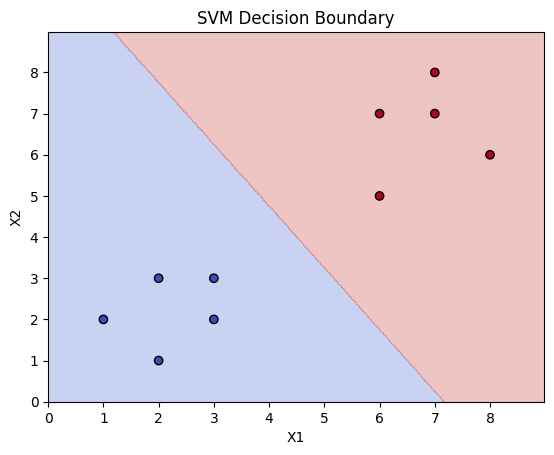

In [ ]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))

# Decision region
ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu', levels=[-0.5, 0.5, 1.5])

# Decision boundary + margin lines
Z_dec = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, Z_dec, levels=[-1, 0, 1],
           linestyles=['--', '-', '--'],
           linewidths=[1.2, 2.0, 1.2],
           colors=['#4da6ff', 'white', '#ff4d4d'])

# Data points
ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=90, edgecolors='white',
           linewidths=0.8, label='Class 0 🔴', zorder=4)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=90, edgecolors='white',
           linewidths=0.8, label='Class 1 🔵', zorder=4)

# Highlight support vectors
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
           s=250, facecolors='none', edgecolors='#ffd700',
           linewidths=2.5, label='Support Vectors ⭐', zorder=5)

# New mystery point
pred_color = '#ff4d4d' if prediction[0] == 0 else '#4da6ff'
ax.scatter(*new_point[0], c=pred_color, s=350, marker='*',
           edgecolors='#ffd700', linewidths=2, label=f'New Point → Class {prediction[0]}', zorder=6)

ax.set_title('SVM Decision Boundary with Margin & Support Vectors',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend(framealpha=0.3, edgecolor='#30363d', fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

print("📌 White line = decision boundary (hyperplane)")
print("📌 Dashed lines = margin boundaries  |  Gold circles = support vectors")

## Section 6 — Effect of the Regularisation Parameter C

The parameter `C` controls the **bias-variance trade-off** in SVM:

| C Value | Margin | Support Vectors | Behaviour |
|---------|--------|-----------------|-----------|
| Very small (e.g. 0.01) | Wide | Many | High bias — underfits, ignores outliers |
| Moderate (e.g. 1) | Balanced | Moderate | Good generalisation |
| Large (e.g. 10–100) | Narrow | Few | Low bias, high variance — may overfit noise |

The four plots compare how increasing C progressively tightens the margin and reduces the number of support vectors. The margin width $\frac{2}{\|\mathbf{w}\|}$ is reported in the summary table.

**Practical guidance:** Select C via cross-validation (e.g. `GridSearchCV`) rather than setting it manually.

In [ ]:
c_values = [0.01, 1, 10, 100]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

xx2, yy2 = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

for ax, c in zip(axes, c_values):
    clf = SVC(kernel='linear', C=c)
    clf.fit(X, y)

    Z2 = clf.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
    Z_dec2 = clf.decision_function(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    ax.contourf(xx2, yy2, Z2, alpha=0.2, cmap='RdBu', levels=[-0.5, 0.5, 1.5])
    ax.contour(xx2, yy2, Z_dec2, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               linewidths=[1.2, 2.0, 1.2],
               colors=['#4da6ff', 'white', '#ff4d4d'])

    ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=70, edgecolors='white', linewidths=0.7, zorder=4)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=70, edgecolors='white', linewidths=0.7, zorder=4)
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=200, facecolors='none', edgecolors='#ffd700', linewidths=2.2, zorder=5)

    pred_c = clf.predict(new_point)[0]
    n_sv = sum(clf.n_support_)
    ax.set_title(f'C = {c}  |  SVs: {n_sv}  |  New Point → Class {pred_c} {"🔴" if pred_c==0 else "🔵"}',
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('X1', fontsize=9)
    ax.set_ylabel('X2', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of C Parameter on SVM Decision Boundary',
             fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 C Parameter Summary:")
print("┌────────┬─────────────────────┬──────────────────┐")
print("│   C    │ Support Vectors     │ Margin Width     │")
print("├────────┼─────────────────────┼──────────────────┤")
for c in c_values:
    clf = SVC(kernel='linear', C=c)
    clf.fit(X, y)
    n_sv = sum(clf.n_support_)
    margin = 2 / np.linalg.norm(clf.coef_)
    print(f"│ {c:<6} │ {n_sv:<19} │ {margin:.4f}           │")
print("└────────┴─────────────────────┴──────────────────┘")

In [ ]:
---

## Summary

### Algorithm Steps

| Step | Operation |
|------|-----------|
| 1 | Receive labelled training data |
| 2 | Solve the quadratic optimisation problem to find $\mathbf{w}$ and $b$ |
| 3 | Identify support vectors — the subset of points that define the boundary |
| 4 | For a new point, compute the decision score $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$ |
| 5 | Assign the class based on the sign of the score |

### Key Properties

| Property | Detail |
|----------|--------|
| **Type** | Supervised, discriminative, margin-based classifier |
| **Training complexity** | O(n²) to O(n³) depending on solver |
| **Prediction complexity** | O(n_sv · d) — depends on number of support vectors |
| **Key hyperparameters** | C (regularisation), kernel type, kernel parameters (e.g. γ for RBF) |
| **Common kernels** | Linear, RBF (Gaussian), Polynomial, Sigmoid |
| **Requires feature scaling** | Yes — always standardise features before fitting |

### When to Use SVM

- Binary classification with a clear or approximately linear margin
- High-dimensional data (e.g. text classification, genomics) where n_features >> n_samples
- Small to medium datasets where training time is acceptable

### Limitations

- Does not directly produce probability estimates (requires Platt scaling via `probability=True`)
- Training is slow on large datasets (>100k samples)
- Sensitive to the choice of kernel and hyperparameters — requires careful tuning
- Not naturally suited to multi-class problems (uses one-vs-one decomposition by default)